# Continuous DM Injection: PDE vs GF Convolutions

Three-way comparison of continuous DM injection spectra:

1. **Direct PDE solver** (full Boltzmann, temperature shift stripped via photon number conservation)
2. **CosmoTherm GF convolution** (`convolve_cosmotherm_gf` using stored database)
3. **PDE GF table convolution** (single-burst PDE entries convolved with heating rate, G_bb stripped)

Scenarios:
- **Decaying particle**: $z_X = 5 \times 10^4$, $f_X / z_X = 5$ eV
- **s-wave annihilation**: $f_{\rm ann}^{\rm CT} = 10^{-22}$ eV/s
- **p-wave annihilation**: $f_{\rm ann}^{\rm CT} = 10^{-26}$ eV/s

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sys, pathlib
sys.path.insert(0, str(pathlib.Path("../../python").resolve()))

from spectroxide import (
    apply_style, C, SINGLE_COL, DOUBLE_COL,
    run_sweep, solve, delta_n_to_delta_I, g_bb, KAPPA_C,
    hubble, n_hydrogen, rho_gamma, cosmic_time,
    DEFAULT_COSMO,
)
from spectroxide.greens import COSMOTHERM_GF_COSMO
from spectroxide.cosmotherm import (
    load_greens_database,
    convolve_cosmotherm_gf, strip_gbb,
    ct_heating_rate_swave, ct_heating_rate_pwave, ct_heating_rate_decay,
    cosmotherm_gf_distortion,
)
from spectroxide.plot_params import (
    LW, LW_THIN, LW_AXIS, ANNOT_SIZE, LEGEND_SIZE,
    RESID_BAND, RESID_BAND_ALPHA, RESID_MASK_FRAC,
    SAVE_DPI,
)

apply_style()

_K_B = 1.380_649e-23
_H_PL = 6.626_070_15e-34
_T_CMB = 2.726

colors = {"Decay": C["blue"], "s-wave": C["orange"], "p-wave": C["teal"]}

## 1. DM Scenario Parameters

CosmoTherm uses native parameters ($f_{\rm ann}$ in eV/s, $f_X$ in eV).
For the PDE solver we convert: $f_{\rm ann}^{\rm ours} = f_{\rm ann}^{\rm CT} / n_{H,0}$.

In [3]:
# CosmoTherm fiducial parameters
f_ann_CT_sw = 1e-22   # s-wave [eV/s]
f_ann_CT_pw = 1e-26   # p-wave [eV/s]
z_X = 5e4             # decay redshift
f_over_zX = 5.0       # f_X / z_X [eV]
f_X_CT = f_over_zX * z_X  # = 2.5e5 eV

# Convert for PDE solver
cosmo = DEFAULT_COSMO
n_H_0 = n_hydrogen(0, cosmo)
f_ann_sw = f_ann_CT_sw / n_H_0
f_ann_pw = f_ann_CT_pw / n_H_0
gamma_x = 1.0 / cosmic_time(z_X + 10, cosmo)

print(f"n_H,0 = {n_H_0:.4f} m^-3")
print(f"s-wave: f_ann = {f_ann_sw:.3e} eV*m^3/s")
print(f"p-wave: f_ann = {f_ann_pw:.3e} eV*m^3/s")
print(f"Decay:  Gamma_X = {gamma_x:.3e}/s, f_X = {f_X_CT:.0f} eV")

# Integration range matching CosmoTherm
Z_START = 5e6
Z_END = 1001
N_POINTS = 2000       # for direct PDE (continuous injection)
N_POINTS_GF = 4000    # for GF table entries — need higher res at z > 1e6
                      # where DC/BR thermalization requires fine low-x grid

n_H,0 = 0.1893 m^-3
s-wave: f_ann = 5.283e-22 eV*m^3/s
p-wave: f_ann = 5.283e-26 eV*m^3/s
Decay:  Gamma_X = 1.072e-10/s, f_X = 250000 eV


## 2. Python GF Convolution

Load the CosmoTherm GF database and convolve with each DM heating rate
using the new `convolve_cosmotherm_gf` function.

In [4]:
z_h_ct, x_ct, g_th_ct = load_greens_database()
print(f"GF database: {len(z_h_ct)} redshifts x {len(x_ct)} frequencies")
print(f"  z range: [{z_h_ct.min():.0f}, {z_h_ct.max():.0f}]")

ct_heating = {
    "Decay":  lambda z: ct_heating_rate_decay(z, f_X_CT, gamma_x),
    "s-wave": lambda z: ct_heating_rate_swave(z, f_ann_CT_sw),
    "p-wave": lambda z: ct_heating_rate_pwave(z, f_ann_CT_pw),
}

# convolve_cosmotherm_gf returns (x_out, di_Jy) where x_out is dimensionless x
gf_conv = {}
for name, dq_func in ct_heating.items():
    x_out, di = convolve_cosmotherm_gf(
        z_h_ct, x_ct, g_th_ct, dq_func,
        z_min=Z_END, z_max=Z_START, n_z=2000,
    )
    # Convert x → ν [GHz] for storage; both are useful downstream
    nu_out = x_out * _K_B * _T_CMB / _H_PL / 1e9
    gf_conv[name] = (x_out, nu_out, di)  # (dimensionless x, ν GHz, Jy/sr)
    print(f"  {name}: peak |DI| = {np.max(np.abs(di)):.4e} Jy/sr")

GF database: 118 redshifts x 4190 frequencies
  z range: [1000, 5000000]


  Decay: peak |DI| = 1.5112e+03 Jy/sr


  s-wave: peak |DI| = 9.4378e+00 Jy/sr


  p-wave: peak |DI| = 2.4711e+02 Jy/sr


### 2b. PDE-Derived Green's Function Table

Build a GF table by running single-burst PDE at the CosmoTherm $z_h$ values,
then convolve with the DM heating rates. Unlike CosmoTherm, our
PDE entries include full numerical thermalization — no
`exp(-(z/2\times10^6)^{5/2})` factor needed during convolution.

Uses `N_POINTS_GF = 4000` grid points (vs 2000 for direct PDE) because
entries at $z_h > 10^6$ need finer low-$x$ resolution for accurate
DC/BR thermalization. Strip $G_{bb}$ from the convolved result via
photon number conservation.

In [5]:
# Build PDE-derived Green's function table by running single-burst
# injections at many z_h values, then convolve with DM heating rates.
# Our PDE entries include full numerical thermalization — no exp factor needed.
#
# Uses N_POINTS_GF (4000) with production grid settings:
#   x_min=1e-5, x_max=60, x_transition=0.05, log_fraction=0.25
# This gives better DC/BR resolution at high z_h (z > 1e6).
#
# The table is cached to disk (~15 MB) to skip the ~11 min rebuild.
# Delete the cache file to force a fresh rebuild.

import time

DELTA_RHO_GF = 1e-5  # injection amplitude for GF table

# z_h grid: match CosmoTherm database redshifts
z_h_pde = z_h_ct

CACHE_PATH = pathlib.Path("../data/pde_gf_table_cache.npz")

if CACHE_PATH.exists():
    cached = np.load(CACHE_PATH)
    x_pde_gf = cached["x"]
    pde_gf_table = cached["gf_table"]
    z_h_cached = cached["z_h"]
    n_pts_cached = int(cached["n_points"])
    # Validate cache matches current parameters
    if (len(z_h_cached) == len(z_h_pde)
            and np.allclose(z_h_cached, z_h_pde, rtol=1e-10)
            and n_pts_cached == N_POINTS_GF):
        print(f"Loaded PDE GF table from cache: {CACHE_PATH}")
        print(f"  {pde_gf_table.shape[1]} z_h values, {pde_gf_table.shape[0]} x points")
    else:
        print(f"Cache stale (z_h or n_points changed), rebuilding...")
        CACHE_PATH.unlink()
        CACHE_PATH = None  # force rebuild below

if not CACHE_PATH or not CACHE_PATH.exists():
    print(f"Building PDE GF table: {len(z_h_pde)} z_h values, N={N_POINTS_GF} grid points (production grid)")
    print(f"  z_h range: [{z_h_pde.min():.0f}, {z_h_pde.max():.1e}]")

    t0 = time.time()
    sw_gf = run_sweep(
        delta_rho=DELTA_RHO_GF,
        z_injections=z_h_pde.tolist(),
        z_end=Z_END,
        n_points=N_POINTS_GF,
        production_grid=True,
        timeout=7200,
    )
    dt = time.time() - t0
    print(f"  Done in {dt:.0f}s ({dt/len(z_h_pde):.1f}s per z_h)")

    # Extract x grid and build (N_x, N_z) table of delta_n / delta_rho
    x_pde_gf = np.array(sw_gf["results"][0]["x"])
    n_x = len(x_pde_gf)
    n_zh = len(z_h_pde)
    pde_gf_table = np.zeros((n_x, n_zh))
    for j, r in enumerate(sw_gf["results"]):
        pde_gf_table[:, j] = np.array(r["delta_n"]) / DELTA_RHO_GF

    # Save to cache
    CACHE_PATH = pathlib.Path("../data/pde_gf_table_cache.npz")
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(CACHE_PATH, x=x_pde_gf, gf_table=pde_gf_table,
                        z_h=z_h_pde, n_points=N_POINTS_GF)
    print(f"  Saved cache to {CACHE_PATH} ({CACHE_PATH.stat().st_size / 1e6:.1f} MB)")

print(f"  Table shape: {pde_gf_table.shape} (N_x × N_z)")

Loaded PDE GF table from cache: ../data/pde_gf_table_cache.npz
  118 z_h values, 4000 x points
  Table shape: (4000, 118) (N_x × N_z)


In [6]:
# Convolve PDE GF table with DM heating rates.
# Unlike CosmoTherm, our PDE entries include full thermalization,
# so we do NOT apply exp(-(z/2e6)^{5/2}) during convolution.
from scipy.interpolate import RegularGridInterpolator

log_x_pde = np.log10(x_pde_gf)
log_zh_pde = np.log10(z_h_pde)
interp_pde = RegularGridInterpolator(
    (log_x_pde, log_zh_pde), pde_gf_table,
    method="linear", bounds_error=False, fill_value=0.0,
)

def convolve_pde_gf(dq_dz, z_min=Z_END, z_max=Z_START, n_z=2000):
    """Convolve PDE GF table with heating rate (no exp factor)."""
    ln_min = np.log(1.0 + z_min)
    ln_max = np.log(1.0 + z_max)
    ln_grid = np.linspace(ln_min, ln_max, n_z)
    dln = ln_grid[1] - ln_grid[0]

    di = np.zeros(len(x_pde_gf))
    for j in range(n_z):
        z_j = np.exp(ln_grid[j]) - 1.0
        heating = dq_dz(z_j) * (1.0 + z_j)  # d(Drho/rho)/dz × (1+z) for d(ln(1+z))
        if abs(heating) < 1e-50:
            continue

        # Interpolate PDE GF at this z
        log_zj = np.full(len(x_pde_gf), np.log10(max(z_j, z_h_pde.min())))
        pts = np.column_stack([log_x_pde, log_zj])
        gf_vals = interp_pde(pts)

        w = 0.5 * dln if (j == 0 or j == n_z - 1) else dln
        di += gf_vals * heating * w

    # Convert delta_n to Jy/sr
    nu_hz = x_pde_gf * _K_B * _T_CMB / _H_PL
    di_si = 2.0 * _H_PL * nu_hz**3 / (3e8)**2 * di
    nu_ghz = nu_hz / 1e9
    return nu_ghz, di_si / 1e-26, di  # nu_ghz, di_jy, delta_n

# Convolve for each scenario, then strip G_bb
pde_gf_conv = {}
pde_gf_conv_no_gbb = {}
for name, dq_func in ct_heating.items():
    nu_pg, di_pg, dn_pg = convolve_pde_gf(dq_func)
    dn_stripped, alpha = strip_gbb(x_pde_gf, dn_pg)
    pde_gf_conv[name] = (nu_pg, di_pg)
    pde_gf_conv_no_gbb[name] = (x_pde_gf, dn_stripped)
    print(f"  {name}: DT/T = {alpha:+.3e},  peak |DI| = {np.max(np.abs(di_pg)):.4e} Jy/sr")


  Decay: DT/T = +5.240e-10,  peak |DI| = 1.5095e+03 Jy/sr


  s-wave: DT/T = +1.055e-09,  peak |DI| = 1.0380e+01 Jy/sr


  p-wave: DT/T = +2.847e-07,  peak |DI| = 6.0204e+02 Jy/sr


### Test `cosmotherm_gf_distortion` convenience wrapper

In [7]:
# Quick check that the convenience wrapper gives the same result
x_w, nu_w, di_w = cosmotherm_gf_distortion(
    "swave", {"f_ann_CT": f_ann_CT_sw},
    z_h=z_h_ct, x=x_ct, g_th=g_th_ct,
    z_min=Z_END, z_max=Z_START, n_z=2000,
)
_, _, di_ref = gf_conv["s-wave"]
rms_wrapper = np.sqrt(np.mean((di_w - di_ref)**2)) / np.max(np.abs(di_ref))
print(f"Wrapper vs direct: relative RMS = {rms_wrapper:.2e} (should be ~0)")

Wrapper vs direct: relative RMS = 0.00e+00 (should be ~0)


## 3. Direct PDE Solver

Run the PDE solver for each DM scenario as ground truth.

In [ ]:
dm_injections = {
    "Decay": {"type": "decaying-particle", "f_x": f_X_CT, "gamma_x": gamma_x},
    "s-wave": {"type": "annihilating-dm", "f_ann": f_ann_sw},
    "p-wave": {"type": "annihilating-dm-pwave", "f_ann": f_ann_pw},
}

PDE_CACHE = pathlib.Path("../data/pde_dm_results_nc_cache.npz")

pde_results = {}
if PDE_CACHE.exists():
    cached = np.load(PDE_CACHE, allow_pickle=True)
    cached_params = cached["params"].item()  # dict
    # Validate: check z_start, z_end, n_points match
    if (cached_params.get("z_start") == Z_START
            and cached_params.get("z_end") == Z_END
            and cached_params.get("n_points") == N_POINTS):
        for name in ["Decay", "s-wave", "p-wave"]:
            pde_results[name] = {
                "x": cached[f"{name}_x"],
                "delta_n": cached[f"{name}_dn"],
                "pde_mu": float(cached[f"{name}_mu"]),
                "pde_y": float(cached[f"{name}_y"]),
                "drho": float(cached[f"{name}_drho"]),
            }
        print(f"Loaded PDE results from cache: {PDE_CACHE}")
    else:
        print("Cache stale (parameters changed), rebuilding...")
        PDE_CACHE.unlink()

if not pde_results:
    for name, inj in dm_injections.items():
        print(f"Running PDE: {name}...")
        sw = solve(
            injection=inj, delta_rho=1e-5,
            z_start=Z_START, z_end=Z_END, n_points=N_POINTS,
            timeout=1200,
            production_grid=True,
            number_conserving=True,
        )
        pde_results[name] = {"x": sw.x.tolist(), "delta_n": sw.delta_n.tolist(),
                             "pde_mu": sw.mu, "pde_y": sw.y,
                             "drho": sw.delta_rho_over_rho, "z_h": sw.z_h}

    # Save to cache
    save_dict = {"params": {"z_start": Z_START, "z_end": Z_END, "n_points": N_POINTS}}
    for name in ["Decay", "s-wave", "p-wave"]:
        r = pde_results[name]
        save_dict[f"{name}_x"] = np.array(r["x"])
        save_dict[f"{name}_dn"] = np.array(r["delta_n"])
        save_dict[f"{name}_mu"] = r.get("pde_mu", r.get("mu", 0))
        save_dict[f"{name}_y"] = r.get("pde_y", r.get("y", 0))
        save_dict[f"{name}_drho"] = r.get("drho", r.get("delta_rho_over_rho", 0))
    PDE_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(PDE_CACHE, **save_dict)
    print(f"Saved PDE results cache: {PDE_CACHE}")

for name in ["Decay", "s-wave", "p-wave"]:
    r = pde_results[name]
    mu = r.get("pde_mu", r.get("mu", 0))
    y = r.get("pde_y", r.get("y", 0))
    drho = r.get("drho", r.get("delta_rho_over_rho", 0))
    print(f"  {name}: mu={mu:.3e}, y={y:.3e}, Drho/rho={drho:.3e}")

## 4. Strip Unobservable Temperature Shift from PDE

FIRAS measures the CMB spectrum with $T$ as a free parameter, so a uniform
temperature shift $\Delta T/T$ is unobservable. CosmoTherm defines the
*distortion* as the number-conserving part of $\Delta n$: the part satisfying
$\int x^2 \Delta n \, dx = 0$ (Chluba & Sunyaev 2012). Any nonzero photon
number is attributed to a temperature shift $\alpha \cdot G_{bb}(x)$.

This projection is orthogonal to $\mu$ and $y$ because both $M(x)$ and $Y_{SZ}(x)$
conserve photon number ($\int x^2 M \, dx \approx 0$). No cross-talk.

The CosmoTherm GF database stores number-conserving entries by construction,
so we only need to strip from the PDE output.

In [9]:
# Strip unobservable temperature shift from PDE (photon number conservation)
# CosmoTherm GF entries are already number-conserving — no stripping needed there.
pde_no_gbb = {}
for name, r in pde_results.items():
    x_pde = np.array(r["x"])
    dn_pde = np.array(r["delta_n"])
    dn_stripped, alpha = strip_gbb(x_pde, dn_pde)
    pde_no_gbb[name] = (x_pde, dn_stripped)
    print(f"{name:>7s}: DT/T = {alpha:+.3e}")

  Decay: DT/T = +6.027e-10
 s-wave: DT/T = +1.005e-09
 p-wave: DT/T = +2.870e-07


## 5. CosmoTherm SWIG Cross-check (optional)

If the SWIG bindings are available, load them for an additional comparison.

In [10]:
ct_swig = {}
has_swig = False

try:
    _ct_dir = str(pathlib.Path("../../data/cosmotherm/Greens.v1.0.3/python").resolve())
    if _ct_dir not in sys.path:
        sys.path.insert(0, _ct_dir)
    import Greens as CT_GF

    CT_GF.set_verbosity(0)
    NU_MIN, NU_MAX, DNU = 10.0, 1100.0, 1.0
    nfreq = CT_GF.initialize_Greens_function(NU_MIN, NU_MAX, DNU)
    nu_swig = np.array([NU_MIN + i * DNU for i in range(nfreq)])

    params = {
        "s-wave": (f_ann_CT_sw, 0, 0, 0, 0, 0, 0, 0),
        "p-wave": (f_ann_CT_pw, 1, 0, 0, 0, 0, 0, 0),
        "Decay":  (0, 0, 0, 0, 0, 0, z_X, f_X_CT),
    }

    for name, (f_a, wave, A, k0, nS, nrun, Gam, fX) in params.items():
        Sig = np.ones(nfreq)
        CT_GF.compute_mock_data_binned(Sig, f_a, wave, A, k0, nS, nrun,
                                       Gam, fX, 0.0, 0.0, 0.0)
        ct_swig[name] = (nu_swig, Sig)
        print(f"  SWIG {name}: peak |DI| = {np.max(np.abs(Sig)):.4e} Jy/sr")

    has_swig = True
except (ImportError, OSError) as e:
    print(f"SWIG not available: {e}")

## 6. Spectral Comparison: PDE vs CosmoTherm GF vs PDE GF Table

Three-way comparison for each DM scenario:
1. **Direct PDE** (continuous injection, temperature shift stripped)
2. **CosmoTherm GF convolution** (stored database entries)
3. **PDE GF table convolution** (our PDE-derived single-burst entries convolved with heating rate)

Bottom panels show percent deviation vs CT GF convolution.

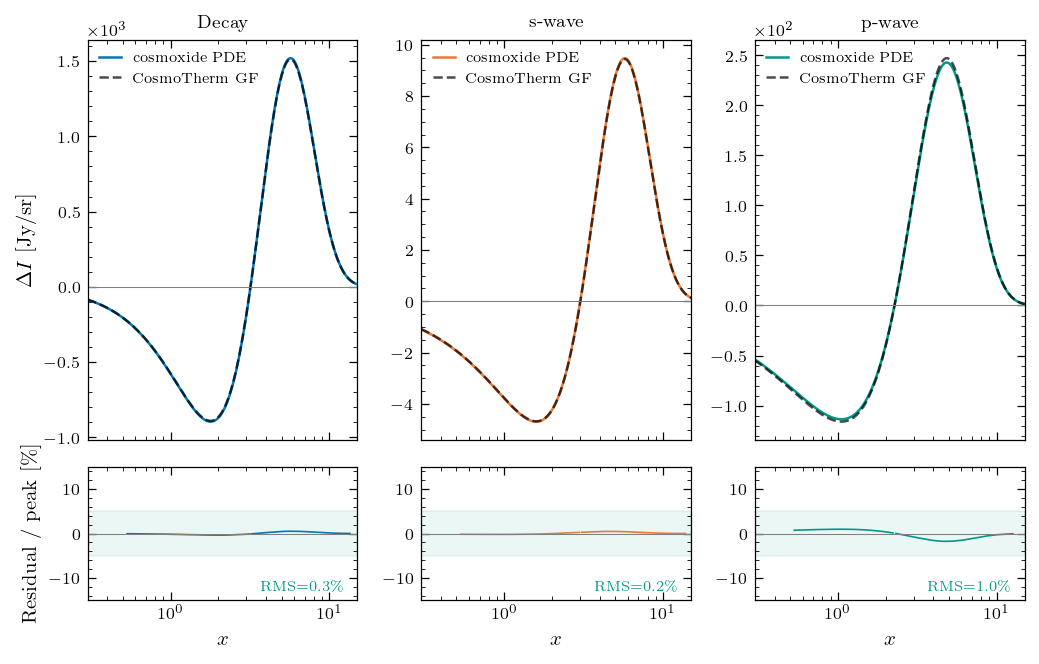

In [10]:
# Per-scenario panels (internal diagnostic — paper figure is the overlay below)
# y-axis: ΔI [Jy/sr] (native GF units, no fragile Δn conversion)
# x-axis: dimensionless x

fig, axes = plt.subplots(2, 3, figsize=(DOUBLE_COL, 4.5),
                         gridspec_kw={"height_ratios": [3, 1]}, sharex="col")

for idx, name in enumerate(["Decay", "s-wave", "p-wave"]):
    ax = axes[0, idx]
    ax_b = axes[1, idx]

    # PDE (temperature shift stripped via photon number conservation)
    x_pde, dn_pde = pde_no_gbb[name]
    nu_pde, di_pde = delta_n_to_delta_I(x_pde, dn_pde)
    ax.plot(x_pde, di_pde, color=colors[name], ls="-", lw=LW,
            label=r"spectroxide PDE")

    # CosmoTherm GF convolution (already number-conserving)
    x_gf, nu_gf, di_gf = gf_conv[name]
    ax.plot(x_gf, di_gf, "k--", lw=LW, alpha=0.7, label=r"CosmoTherm GF")

    ax.axhline(0, color="gray", lw=LW_AXIS)
    ax.set_xscale("log")
    ax.set_xlim(0.3, 15)
    ax.set_title(name)
    if idx == 0:
        ax.set_ylabel(r"$\Delta I$ [Jy/sr]")
    ax.legend(fontsize=LEGEND_SIZE)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

    # Residual: PDE vs CT GF (peak-normalized)
    di_pde_at_gf = np.interp(nu_gf, nu_pde, di_pde)
    peak = np.max(np.abs(di_gf))
    mask = (np.abs(di_gf) > RESID_MASK_FRAC * peak) & (nu_gf > 30) & (nu_gf < 857)
    pct = np.full_like(di_gf, np.nan)
    pct[mask] = (di_pde_at_gf[mask] - di_gf[mask]) / peak * 100
    ax_b.plot(x_gf, pct, color=colors[name], lw=LW_THIN)
    rms = np.sqrt(np.nanmean(pct[mask]**2))

    ax_b.text(0.95, 0.05, f"RMS={rms:.1f}\%",
              transform=ax_b.transAxes,
              ha="right", va="bottom", fontsize=ANNOT_SIZE,
              color=C["teal"] if rms < 10 else C["red"])

    ax_b.axhline(0, color="gray", lw=LW_AXIS)
    ax_b.axhspan(-RESID_BAND, RESID_BAND, color=C["teal"], alpha=RESID_BAND_ALPHA)
    ax_b.set_xscale("log")
    ax_b.set_xlim(0.3, 15)
    ax_b.set_ylim(-15, 15)
    ax_b.set_xlabel(r"$x$")
    if idx == 0:
        ax_b.set_ylabel("Residual / peak [\%]")

fig.tight_layout()
plt.show()

### All Scenarios Overlay

Decay: RMS(PDE vs CT GF) = 0.29%
s-wave: RMS(PDE vs CT GF) = 0.24%
p-wave: RMS(PDE vs CT GF) = 0.98%


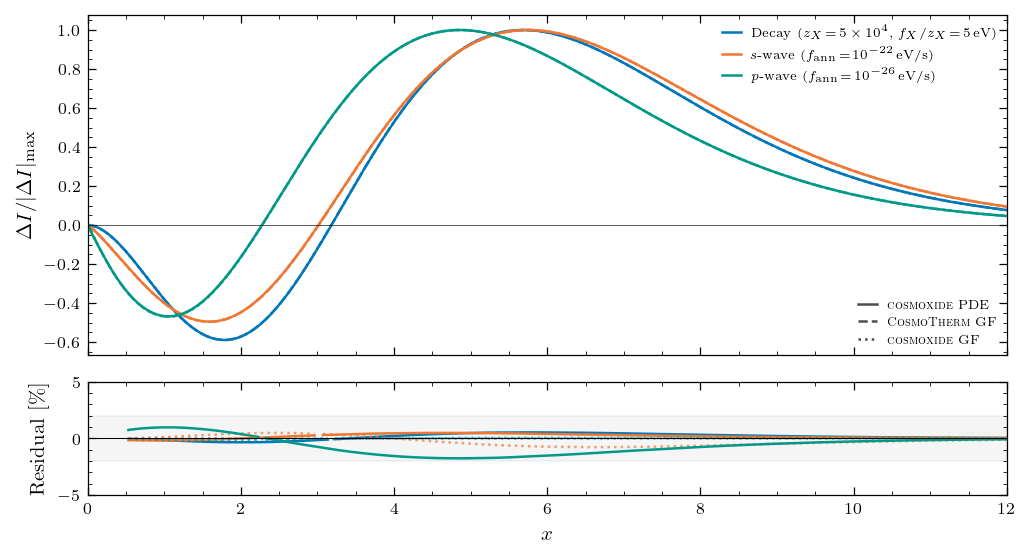

In [11]:
# Paper figure: all DM scenarios overlaid with residual panel
# Three methods: PDE (solid), CosmoTherm GF (dashed), PDE GF (dotted)
# y-axis: ΔI [Jy/sr] normalized by peak (native units, no Δn conversion)
# x-axis: dimensionless x

labels = {"Decay": r"Decay ($\Gamma_X\!=\!1.1\times10^{-10}\,$s$^{-1}$, $f_X\!=\!2.5\times10^5\,$eV)",
          "s-wave": r"$s$-wave ($f_{\rm ann}\!=\!10^{-22}\,$eV/s)",
          "p-wave": r"$p$-wave ($f_{\rm ann}\!=\!10^{-26}\,$eV/s)"}

fig, (ax, ax_b) = plt.subplots(2, 1, figsize=(DOUBLE_COL, 3.8),
                                gridspec_kw={"height_ratios": [3, 1]},
                                sharex=True)

for name in ["Decay", "s-wave", "p-wave"]:
    col = colors[name]

    # PDE (temperature shift stripped) → ΔI [Jy/sr]
    x_pde, dn_pde = pde_no_gbb[name]
    nu_pde, di_pde = delta_n_to_delta_I(x_pde, dn_pde)
    peak_pde = np.max(np.abs(di_pde))

    # CosmoTherm GF convolution — apply strip_gbb for consistency
    x_gf, nu_gf, di_gf_raw = gf_conv[name]
    # Convert CT ΔI [Jy/sr] → Δn, strip G_bb, convert back
    nu_hz = x_gf * _K_B * _T_CMB / _H_PL
    dn_gf_raw = di_gf_raw * 1e-26 * (3e8)**2 / (2.0 * _H_PL * nu_hz**3)
    dn_gf_nc, _ = strip_gbb(x_gf, dn_gf_raw)
    _, di_gf = delta_n_to_delta_I(x_gf, dn_gf_nc)

    # PDE GF convolution (G_bb stripped)
    x_pgf, dn_pgf = pde_gf_conv_no_gbb[name]
    nu_pgf, di_pgf = delta_n_to_delta_I(x_pgf, dn_pgf)

    # Normalize all by PDE peak
    ax.plot(x_pde, di_pde / peak_pde, color=col, ls="-", lw=LW,
            label=labels[name])
    ax.plot(x_gf, di_gf / peak_pde, color=col, ls="--", lw=LW, alpha=0.7)
    ax.plot(x_pgf, di_pgf / peak_pde, color=col, ls=":", lw=LW, alpha=0.7)

    # Residual vs CT GF: (PDE - CT GF) / peak_PDE × 100
    di_pde_at_gf = np.interp(nu_gf, nu_pde, di_pde)
    peak_ref = peak_pde
    mask = (np.abs(di_gf) > RESID_MASK_FRAC * peak_ref) & (nu_gf > 30) & (nu_gf < 857)
    pct = np.full_like(di_gf, np.nan)
    pct[mask] = (di_pde_at_gf[mask] - di_gf[mask]) / peak_ref * 100
    ax_b.plot(x_gf, pct, color=col, ls="-", lw=LW)
    rms_pde = np.sqrt(np.nanmean(pct[mask]**2))

    # Residual vs CT GF: (PDE GF - CT GF) / peak_PDE × 100
    di_pgf_at_gf = np.interp(nu_gf, nu_pgf, di_pgf)
    pct_pgf = np.full_like(di_gf, np.nan)
    pct_pgf[mask] = (di_pgf_at_gf[mask] - di_gf[mask]) / peak_ref * 100
    ax_b.plot(x_gf, pct_pgf, color=col, ls=":", lw=LW, alpha=0.7)

    print(f"{name}: RMS(PDE vs CT GF) = {rms_pde:.2f}%")

ax.axhline(0, color="k", lw=0.3)
ax.set_ylabel(r"$\Delta I / |\Delta I|_{\rm max}$")

# Scenario legend (colors)
leg1 = ax.legend(fontsize=LEGEND_SIZE - 1, loc="upper right", ncol=1)

# Method legend (line styles) — invisible dummy lines
from matplotlib.lines import Line2D
method_handles = [
    Line2D([], [], color="0.3", ls="-",  lw=LW,      label=r"\textsc{spectroxide} PDE"),
    Line2D([], [], color="0.3", ls="--", lw=LW, label=r"\textsc{CosmoTherm} GF"),
    Line2D([], [], color="0.3", ls=":",  lw=LW, label=r"\textsc{spectroxide} GF"),
]
leg2 = ax.legend(handles=method_handles, fontsize=LEGEND_SIZE - 1,
                 loc="lower right")
ax.add_artist(leg1)  # re-add first legend so both show

ax.set_xlim(0, 12)

ax_b.axhline(0, color="k", lw=0.5)
ax_b.axhspan(-2, 2, alpha=RESID_BAND_ALPHA, color="gray")
ax_b.set_ylim(-5, 5)
ax_b.set_xlabel(r"$x$")
ax_b.set_ylabel(r"Residual [\%]")

fig.tight_layout()
plt.savefig("../../notebooks/figures/pde_gf_dm_comparison.pdf", dpi=SAVE_DPI)
plt.show()


## 7. Summary

In [12]:
def _get(d, *keys):
    for k in keys:
        if k in d:
            return d[k]
    return 0.0

def _di_jy_to_dn(x, di_jy):
    """Convert ΔI [Jy/sr] to Δn on dimensionless x grid."""
    nu_hz = x * _K_B * _T_CMB / _H_PL
    return di_jy * 1e-26 * (3e8)**2 / (2.0 * _H_PL * nu_hz**3)

print(f"{'Scenario':<10} {'mu':>10} {'y':>10} {'Drho/rho':>10} {'mu/y':>8}")
print("-" * 50)
for name in ["Decay", "s-wave", "p-wave"]:
    r = pde_results[name]
    mu = _get(r, "pde_mu", "mu")
    y = _get(r, "pde_y", "y")
    drho = _get(r, "drho", "delta_rho_over_rho")
    ratio = abs(mu / y) if abs(y) > 1e-30 else float("inf")
    print(f"{name:<10} {mu:10.3e} {y:10.3e} {drho:10.3e} {ratio:8.2f}")

# Spectral agreement vs CT GF convolution (x ∈ [0.5, 15])
print(f"\nSpectral agreement vs CT GF convolution (x ∈ [0.5, 15]):")
print(f"  {'Scenario':<10} {'PDE':>8} {'PDE GF':>8}")
print(f"  {'-'*28}")
for name in ["Decay", "s-wave", "p-wave"]:
    # PDE vs CT GF — work in ΔI space (native, reliable)
    x_pde, dn_pde = pde_no_gbb[name]
    nu_pde, di_pde = delta_n_to_delta_I(x_pde, dn_pde)

    x_gf, nu_gf, di_gf = gf_conv[name]

    # Interpolate PDE onto GF grid in ν space (well-defined)
    di_pde_at_gf = np.interp(nu_gf, nu_pde, di_pde)
    peak = np.max(np.abs(di_gf))
    mask = (np.abs(di_gf) > 0.03 * peak) & (x_gf > 0.5) & (x_gf < 15)
    rms_pde = np.sqrt(np.mean(((di_pde_at_gf[mask] - di_gf[mask]) / peak)**2)) * 100

    # PDE GF vs CT GF — also in ΔI space
    x_o, dn_o = pde_gf_conv_no_gbb[name]
    nu_o, di_o = delta_n_to_delta_I(x_o, dn_o)
    di_o_at_gf = np.interp(nu_gf, nu_o, di_o)
    rms_our = np.sqrt(np.mean(((di_o_at_gf[mask] - di_gf[mask]) / peak)**2)) * 100

    print(f"  {name:<10} {rms_pde:7.1f}% {rms_our:7.1f}%")

if ct_swig:
    print(f"\nPython GF conv vs SWIG cross-check:")
    for name in ["Decay", "s-wave", "p-wave"]:
        if name not in ct_swig:
            continue
        _, nu_gf, di_gf = gf_conv[name]
        nu_s, di_s = ct_swig[name]
        di_gf_at_s = np.interp(nu_s, nu_gf, di_gf)
        peak = np.max(np.abs(di_s))
        mask = (np.abs(di_s) > 0.03 * peak) & (nu_s > 30) & (nu_s < 857)
        rms = np.sqrt(np.mean(((di_gf_at_s[mask] - di_s[mask]) / peak)**2)) * 100
        print(f"  {name}: {rms:.1f}% RMS vs SWIG (30-857 GHz)")

Scenario           mu          y   Drho/rho     mu/y
--------------------------------------------------
Decay       2.528e-06  5.425e-07  3.239e-06     4.66
s-wave      1.823e-08  2.896e-09  2.660e-08     6.30
p-wave      8.136e-07  5.875e-09  1.727e-06   138.49

Spectral agreement vs CT GF convolution (x ∈ [0.5, 15]):
  Scenario        PDE   PDE GF
  ----------------------------
  Decay          0.3%     0.0%
  s-wave         0.2%     0.4%
  p-wave         1.0%     0.1%

Python GF conv vs SWIG cross-check:
  Decay: 0.1% RMS vs SWIG (30-857 GHz)
  s-wave: 0.9% RMS vs SWIG (30-857 GHz)
  p-wave: 0.0% RMS vs SWIG (30-857 GHz)


### Advanced Diagnostics (Tests A–D)

This section provides detailed diagnostic tests to investigate sources of disagreement:

**Test A**: Entry-by-entry comparison at selected $z_h$ values: PDE entry (numerical thermalization) vs CT entry $	imes\,\exp[-(z/2\times10^6)^{5/2}]$.

**Test B**: Truncated integral — vary $z_{\max}$ in the convolution and compute RMS disagreement vs CT GF. Tests whether discrepancy is driven by thermalization suppression at high-$z$.

**Test C**: Full GF without stripping $G_{bb}$ — compare all three methods (CT reconstructed GF, direct PDE, PDE GF convolution) including temperature shift, to isolate whether discrepancy is in total energy or $G_{bb}$ partition.

**Test D**: Energy and $\Delta T/T$ diagnostic — decompose spectra into total energy, G$_{bb}$ component, and stripped (μ+y) energy. Examine individual PDE GF entry energies at high $z_h$.

## 8. Diagnostic: Thermalization Approximation Test

CosmoTherm stores GF entries **without** thermalization suppression and applies
$\exp[-(z/2\times10^6)^{5/2}]$ analytically during convolution. Our PDE GF
entries include full numerical thermalization. If the analytic approximation
is the source of the ~5% p-wave disagreement, two tests should confirm it:

**Test A**: Entry-by-entry comparison — PDE entry vs CT entry × exp factor.
If they diverge at high $z_h$, the exp factor is an imperfect approximation.

**Test B**: Truncated integral — vary $z_{\max}$ in the convolution for p-wave.
If disagreement only appears when $z_{\max}$ enters the thermalization regime,
that's a smoking gun.

### Test A: Entry-by-Entry — PDE vs CT × exp factor

Compare individual GF entries at selected $z_h$ values. For each $z_h$:
- **PDE entry**: $G_{\rm PDE}(x, z_h) = \Delta n / \Delta\rho$ (full numerical thermalization)
- **CT entry**: $G_{\rm CT,stored}(x, z_h) \times \exp[-(z_h/2\times10^6)^{5/2}]$

Both are stripped of $G_{bb}$ for fair comparison (PDE entries retain temperature shift;
CT entries are already number-conserving by construction).

If the analytic factor is exact, the ratio PDE/CT should be 1 at all frequencies.

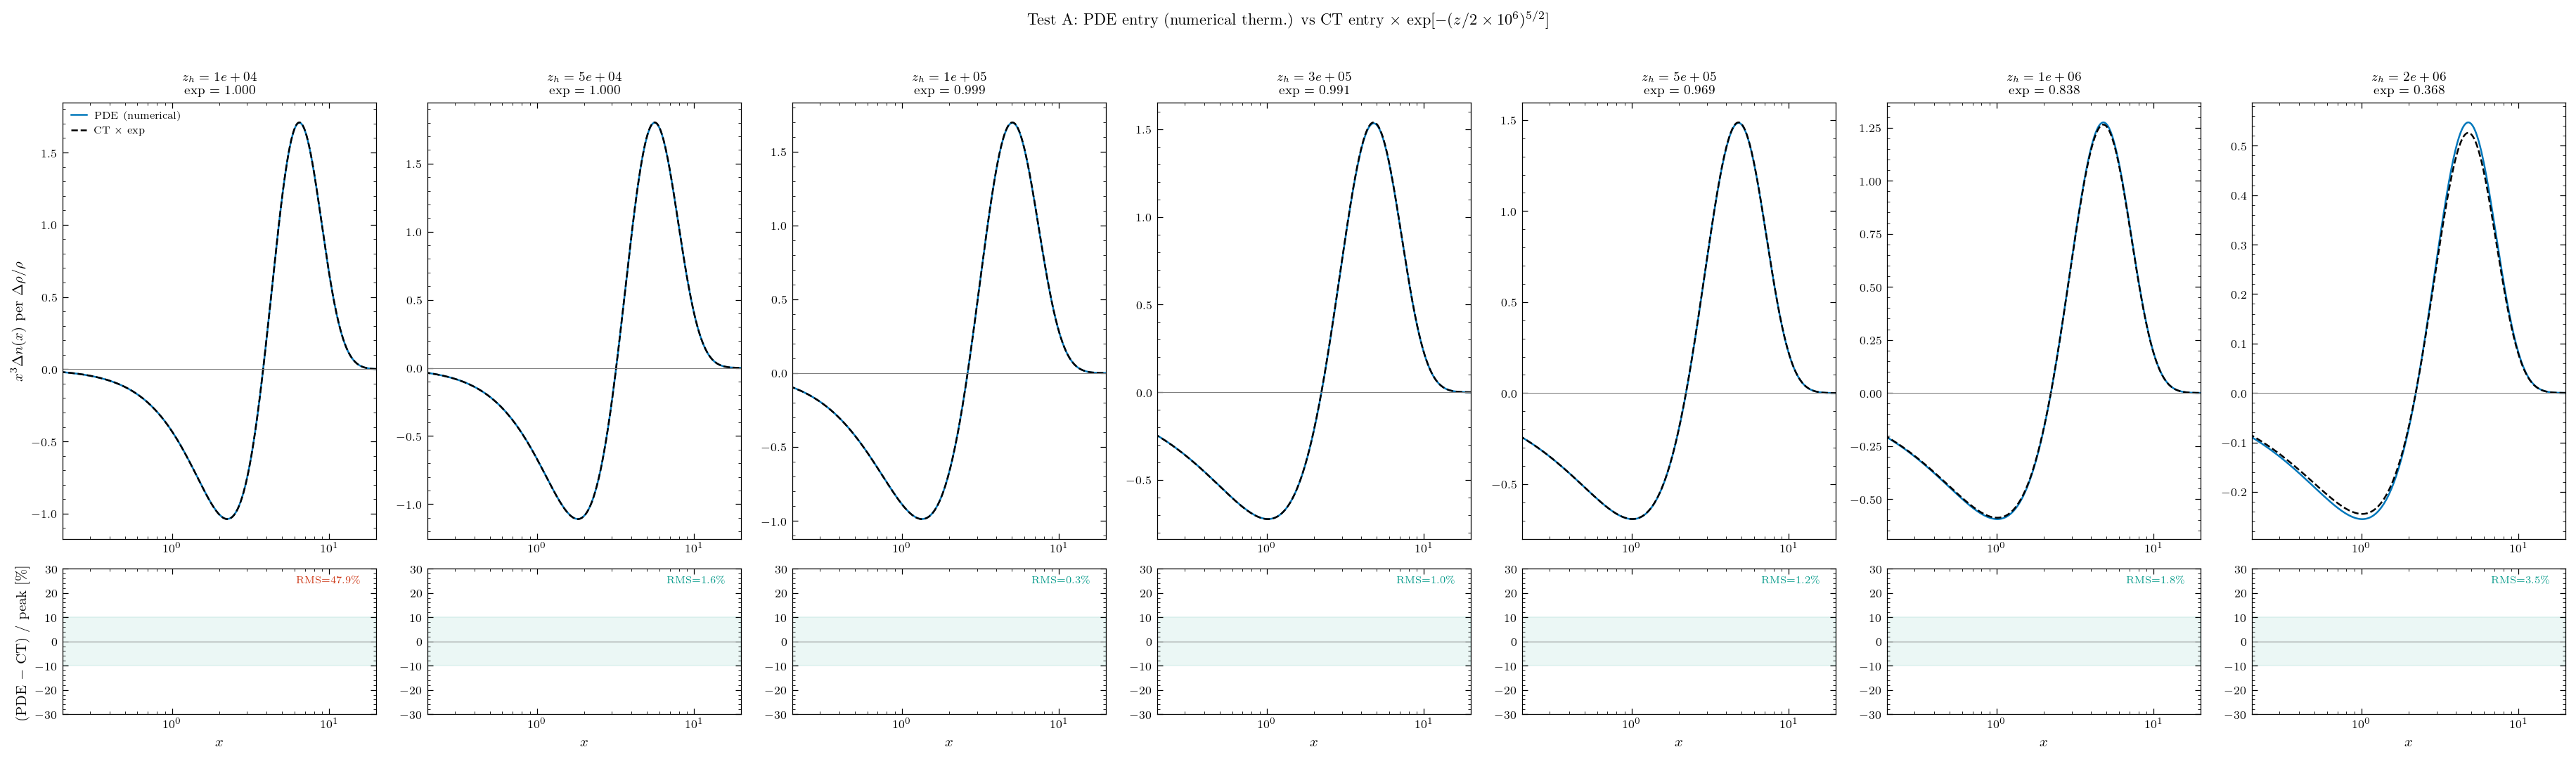

In [13]:
# Test A: Entry-by-entry comparison at selected z_h values
# Compare PDE entry (numerical thermalization) vs CT entry × exp factor
#
# Units:
#   CT GF database (g_th_ct): Jy/sr per unit Δρ/ρ
#   PDE GF table (pde_gf_table): Δn per unit Δρ/ρ
# Convert CT entries from Jy/sr → Δn for apples-to-apples comparison in x-space.

from scipy.interpolate import interp1d

test_zh = [1e4, 5e4, 1e5, 3e5, 5e5, 1e6, 2e6]

# Build CT interpolator for individual entries
log_x_ct = np.log10(x_ct)
log_zh_ct = np.log10(z_h_ct)
ct_interp_2d = RegularGridInterpolator(
    (log_x_ct, log_zh_ct), g_th_ct,
    method="linear", bounds_error=False, fill_value=0.0,
)

# Common x grid for comparison (use PDE grid, restricted to CT range)
x_common = x_pde_gf[(x_pde_gf >= x_ct.min()) & (x_pde_gf <= x_ct.max())]

fig, axes = plt.subplots(2, len(test_zh), figsize=(3.5 * len(test_zh), 7),
                         gridspec_kw={"height_ratios": [3, 1]})

for col, zh in enumerate(test_zh):
    ax = axes[0, col]
    ax_b = axes[1, col]

    exp_factor = np.exp(-(zh / 2.0e6) ** 2.5)

    # PDE entry: Δn/Δρ → strip G_bb (stays in Δn space)
    log_zh_val = np.log10(max(zh, z_h_pde.min()))
    pts_pde = np.column_stack([np.log10(x_common),
                                np.full(len(x_common), log_zh_val)])
    pde_entry_dn = interp_pde(pts_pde)
    pde_stripped, alpha_pde = strip_gbb(x_common, pde_entry_dn)

    # CT entry × exp factor: Jy/sr → Δn
    log_zh_ct_val = np.log10(max(zh, z_h_ct.min()))
    pts_ct = np.column_stack([np.log10(x_common),
                               np.full(len(x_common), log_zh_ct_val)])
    di_ct_entry = ct_interp_2d(pts_ct) * exp_factor  # Jy/sr per Δρ/ρ
    nu_hz = x_common * _K_B * _T_CMB / _H_PL
    dn_ct_entry = di_ct_entry * 1e-26 * (3e8)**2 / (2.0 * _H_PL * nu_hz**3)

    ax.plot(x_common, x_common**3 * pde_stripped, color=C["blue"], ls="-", lw=LW,
            label="PDE (numerical)")
    ax.plot(x_common, x_common**3 * dn_ct_entry, "k--", lw=LW, label=r"CT $\times$ exp")
    ax.axhline(0, color="gray", lw=LW_AXIS)
    ax.set_xscale("log")
    ax.set_xlim(0.2, 20)
    ax.set_title(f"$z_h = {zh:.0e}$\nexp = {exp_factor:.3f}")
    if col == 0:
        ax.set_ylabel(r"$x^3 \Delta n(x)$ per $\Delta\rho/\rho$")
        ax.legend(fontsize=LEGEND_SIZE)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

    # Residual: (PDE - CT) / peak_CT × 100
    peak = np.max(np.abs(dn_ct_entry))
    if peak > 0:
        mask = np.abs(dn_ct_entry) > 0.05 * peak
        pct = np.full_like(dn_ct_entry, np.nan)
        pct[mask] = (pde_stripped[mask] - dn_ct_entry[mask]) / peak * 100
        ax_b.plot(x_common, pct, color=C["blue"], lw=LW_THIN)
        rms = np.sqrt(np.nanmean(pct[mask]**2))
        ax_b.text(0.95, 0.95, f"RMS={rms:.1f}\%", transform=ax_b.transAxes,
                  ha="right", va="top", fontsize=ANNOT_SIZE,
                  color=C["teal"] if rms < 5 else (C["orange"] if rms < 10 else C["red"]))
    ax_b.axhline(0, color="gray", lw=LW_AXIS)
    ax_b.axhspan(-10, 10, color=C["teal"], alpha=RESID_BAND_ALPHA)
    ax_b.set_xscale("log")
    ax_b.set_xlim(0.2, 20)
    ax_b.set_ylim(-30, 30)
    ax_b.set_xlabel(r"$x$")
    if col == 0:
        ax_b.set_ylabel("(PDE $-$ CT) / peak [\%]")

fig.suptitle(r"Test A: PDE entry (numerical therm.) vs CT entry $\times\,\exp[-(z/2\times10^6)^{5/2}]$",
             y=1.02)
fig.tight_layout()
plt.savefig("../figures/pde_thermalization_test_a.pdf", dpi=SAVE_DPI)
plt.show()

  p-wave z_max=1e+04: RMS = 0.43%
  p-wave z_max=3e+04: RMS = 0.12%
  p-wave z_max=1e+05: RMS = 0.04%
  p-wave z_max=3e+05: RMS = 0.05%
  p-wave z_max=5e+05: RMS = 0.07%
  p-wave z_max=1e+06: RMS = 0.09%
  p-wave z_max=2e+06: RMS = 0.55%
  p-wave z_max=3e+06: RMS = 0.68%
  s-wave z_max=1e+04: RMS = 1.74%
  s-wave z_max=3e+04: RMS = 1.07%
  s-wave z_max=1e+05: RMS = 0.75%
  s-wave z_max=3e+05: RMS = 0.62%
  s-wave z_max=5e+05: RMS = 0.58%
  s-wave z_max=1e+06: RMS = 0.51%
  s-wave z_max=2e+06: RMS = 0.43%
  s-wave z_max=3e+06: RMS = 0.41%


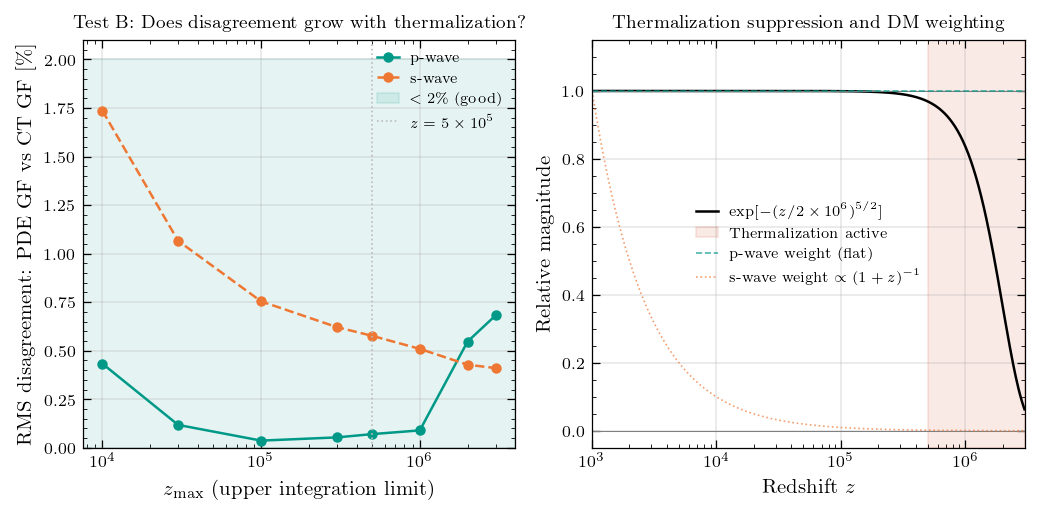

In [14]:
# Test B: Truncated integral — RMS(PDE GF vs CT GF) as a function of z_max
# Run for both p-wave and s-wave to see the z-weighting effect.

z_max_vals = [1e4, 3e4, 1e5, 3e5, 5e5, 1e6, 2e6, 3e6]

results_b = {}
for scenario in ["p-wave", "s-wave"]:
    dq_func = ct_heating[scenario]
    rms_list = []
    for z_max in z_max_vals:
        # CT GF convolution with truncated z_max
        _, di_ct_trunc = convolve_cosmotherm_gf(
            z_h_ct, x_ct, g_th_ct, dq_func,
            z_min=Z_END, z_max=z_max, n_z=2000,
        )
        nu_ct_trunc = x_ct * _K_B * _T_CMB / _H_PL / 1e9

        # PDE GF convolution with truncated z_max
        _, _, dn_pde_trunc = convolve_pde_gf(dq_func, z_max=z_max)
        dn_pde_trunc_nc, _ = strip_gbb(x_pde_gf, dn_pde_trunc)
        nu_pde_trunc, di_pde_trunc = delta_n_to_delta_I(x_pde_gf, dn_pde_trunc_nc)

        # Compute RMS on CT grid (30-857 GHz)
        di_pde_at_ct = np.interp(nu_ct_trunc, nu_pde_trunc, di_pde_trunc)
        peak = np.max(np.abs(di_ct_trunc))
        if peak < 1e-50:
            rms_list.append(0.0)
            continue
        mask = (np.abs(di_ct_trunc) > RESID_MASK_FRAC * peak) & (nu_ct_trunc > 30) & (nu_ct_trunc < 857)
        if mask.sum() == 0:
            rms_list.append(0.0)
            continue
        rms = np.sqrt(np.mean(((di_pde_at_ct[mask] - di_ct_trunc[mask]) / peak)**2)) * 100
        rms_list.append(rms)
        print(f"  {scenario} z_max={z_max:.0e}: RMS = {rms:.2f}%")

    results_b[scenario] = rms_list

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(DOUBLE_COL, 3.5))

# Left: RMS vs z_max
for scenario, ls in [("p-wave", "-"), ("s-wave", "--")]:
    ax1.plot(z_max_vals, results_b[scenario], f"o{ls}", lw=LW,
             color=colors[scenario], label=scenario, markersize=4)
ax1.axhspan(0, 2, color=C["teal"], alpha=0.1, label=r"$<2\%$ (good)")
ax1.axvline(5e5, color=C["gray"], ls=":", lw=LW_THIN, label=r"$z = 5\times10^5$")
ax1.set_xscale("log")
ax1.set_xlabel(r"$z_{\max}$ (upper integration limit)")
ax1.set_ylabel("RMS disagreement: PDE GF vs CT GF [\%]")
ax1.set_title("Test B: Does disagreement grow with thermalization?")
ax1.legend(fontsize=LEGEND_SIZE)
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)

# Right: exp factor and p-wave integrand weighting
z_plot = np.logspace(3, np.log10(3e6), 500)
exp_vals = np.exp(-(z_plot / 2e6)**2.5)
ax2.plot(z_plot, exp_vals, "k-", lw=LW, label=r"$\exp[-(z/2\times10^6)^{5/2}]$")
ax2.axhline(1, color="gray", lw=LW_AXIS)
ax2.axhline(0, color="gray", lw=LW_AXIS)
ax2.axvspan(5e5, 3e6, color=C["red"], alpha=0.1, label="Thermalization active")

# Show p-wave and s-wave relative integrand weighting
pw_weight = np.ones_like(z_plot)  # flat in z
sw_weight = 1.0 / (1.0 + z_plot)  # ∝ (1+z)^{-1}
pw_weight /= pw_weight.max()
sw_weight /= sw_weight.max()
ax2.plot(z_plot, pw_weight, color=C["teal"], ls="--", lw=LW_THIN, alpha=0.7,
         label="p-wave weight (flat)")
ax2.plot(z_plot, sw_weight, color=C["orange"], ls=":", lw=LW_THIN, alpha=0.7,
         label=r"s-wave weight $\propto (1+z)^{-1}$")

ax2.set_xscale("log")
ax2.set_xlabel(r"Redshift $z$")
ax2.set_ylabel("Relative magnitude")
ax2.set_title("Thermalization suppression and DM weighting")
ax2.legend(fontsize=LEGEND_SIZE)
ax2.set_xlim(1e3, 3e6)
ax2.set_ylim(-0.05, 1.15)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig("../figures/pde_thermalization_test_b.pdf", dpi=SAVE_DPI)
plt.show()

### Interpretation

**Test A** shows whether the analytic $\exp[-(z/2\times10^6)^{5/2}]$
factor accurately reproduces the full numerical thermalization at each $z_h$.
Deviations growing with $z_h$ (especially frequency-dependent deviations)
confirm the approximation is imperfect.

**Test B** shows whether the p-wave disagreement is driven by high-$z$
contributions where thermalization matters:
- If RMS is flat and small for $z_{\max} < 5\times10^5$ then rises sharply:
  thermalization approximation is the cause.
- If RMS is already large at low $z_{\max}$: something else
  (cosmology, interpolation, G_bb stripping) dominates.
- The right panel shows why p-wave is more affected: its flat $d(\Delta\rho/\rho)/dz$
  gives equal weight to all redshifts, while s-wave's $\propto(1+z)^{-1}$
  weighting naturally down-weights the thermalization regime.

Reconstructed GF shape: (4190, 118)
Tgin range: [2.7260, 2.7260] K
Tglast range: [2.7260, 2.7260] K
DT/T range: [0.000e+00, 2.500e-07]


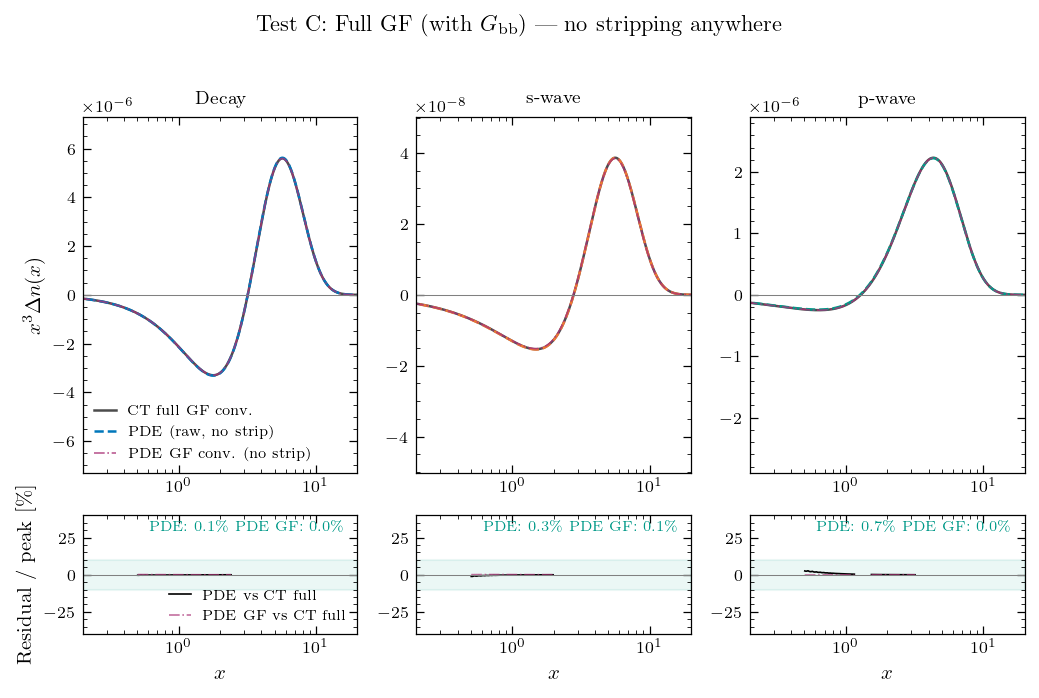


Test C: RMS disagreement vs CT reconstructed GF (x ∈ [0.5, 15]):
  Scenario        PDE   PDE GF
  ----------------------------
  Decay          0.1%     0.0%
  s-wave         0.3%     0.1%
  p-wave         0.7%     0.0%


In [15]:
# Test C: Compare all three methods WITHOUT stripping G_bb
# Use reconstructed CosmoTherm GF (with temperature shift added back)

from spectroxide.cosmotherm import reconstruct_full_gf

# Load GF database with metadata for reconstruction
z_h_ct_m, x_ct_m, g_th_ct_m, meta = load_greens_database(include_metadata=True)

# Reconstruct full GF: stored × exp + G_bb temperature shift
g_th_full = reconstruct_full_gf(x_ct_m, g_th_ct_m, z_h_ct_m, meta, apply_exp=True)

print(f"Reconstructed GF shape: {g_th_full.shape}")
print(f"Tgin range: [{meta['tgin'].min():.4f}, {meta['tgin'].max():.4f}] K")
print(f"Tglast range: [{meta['tglast'].min():.4f}, {meta['tglast'].max():.4f}] K")
print(f"DT/T range: [{((meta['tglast']-meta['tgin'])/meta['tgin']).min():.3e}, "
      f"{((meta['tglast']-meta['tgin'])/meta['tgin']).max():.3e}]")

# Convolve reconstructed (full) GF with each DM heating rate
log_x_ct_full = np.log10(x_ct_m)
log_zh_ct_full = np.log10(z_h_ct_m)
interp_full = RegularGridInterpolator(
    (log_x_ct_full, log_zh_ct_full), g_th_full,
    method="linear", bounds_error=False, fill_value=0.0,
)

def convolve_full_gf(dq_dz, z_min=Z_END, z_max=Z_START, n_z=2000):
    """Convolve reconstructed (full) GF — exp already applied, G_bb included."""
    ln_min = np.log(1.0 + z_min)
    ln_max = np.log(1.0 + z_max)
    ln_grid = np.linspace(ln_min, ln_max, n_z)
    dln = ln_grid[1] - ln_grid[0]

    log_xq = np.log10(np.clip(x_ct_m, x_ct_m.min(), x_ct_m.max()))
    di = np.zeros(len(x_ct_m))

    for j in range(n_z):
        z_j = np.exp(ln_grid[j]) - 1.0
        dz_dln = 1.0 + z_j
        heating = dq_dz(z_j) * dz_dln
        if abs(heating) < 1e-50:
            continue

        log_zj = np.full(len(x_ct_m), np.log10(max(z_j, z_h_ct_m.min())))
        pts = np.column_stack([log_xq, log_zj])
        gf_vals = interp_full(pts)

        w = 0.5 * dln if (j == 0 or j == n_z - 1) else dln
        di += gf_vals * heating * w

    return x_ct_m, di  # x, DI in Jy/sr

# Helper: convert Jy/sr → Δn on x-grid
def _di_to_dn(x, di_jy):
    nu_hz = x * _K_B * _T_CMB / _H_PL
    return di_jy * 1e-26 * (3e8)**2 / (2.0 * _H_PL * nu_hz**3)

# Run for all three DM scenarios
scenarios = ["Decay", "s-wave", "p-wave"]

fig, axes = plt.subplots(2, 3, figsize=(DOUBLE_COL, 4.5),
                         gridspec_kw={"height_ratios": [3, 1]})

for idx, name in enumerate(scenarios):
    ax = axes[0, idx]
    ax_b = axes[1, idx]

    dq_func = ct_heating[name]

    # 1. CT reconstructed GF convolution (full, with G_bb) → Δn
    x_full, di_full = convolve_full_gf(dq_func)
    dn_full = _di_to_dn(x_full, di_full)

    # 2. Direct PDE — NO G_bb stripping (already in Δn)
    r = pde_results[name]
    x_pde_raw = np.array(r["x"])
    dn_pde_raw = np.array(r["delta_n"])

    # 3. PDE GF convolution — NO G_bb stripping (already in Δn)
    _, di_pde_gf_jy, dn_pde_gf_raw = convolve_pde_gf(dq_func)

    # Plot in x / Δn space
    ax.plot(x_full, x_full**3 * dn_full, "k-", lw=LW, alpha=0.7,
            label="CT full GF conv.")
    ax.plot(x_pde_raw, x_pde_raw**3 * dn_pde_raw, color=colors[name], ls="--", lw=LW,
            label="PDE (raw, no strip)")
    ax.plot(x_pde_gf,x_pde_gf**3 * dn_pde_gf_raw, color=C["purple"], ls="-.", lw=LW_THIN, alpha=0.8,
            label="PDE GF conv. (no strip)")

    ax.axhline(0, color="gray", lw=LW_AXIS)
    ax.set_xscale("log")
    ax.set_xlim(0.2, 20)
    # Auto-scale y-axis based on plotted data
    all_vals = np.concatenate([x_full**3 * dn_full,
                               x_pde_raw**3 * dn_pde_raw])
    ymax = np.max(np.abs(all_vals[np.isfinite(all_vals)])) * 1.3
    ax.set_ylim(-ymax, ymax)
    ax.set_title(name)
    if idx == 0:
        ax.set_ylabel(r"$x^3 \Delta n(x)$")
        ax.legend(fontsize=LEGEND_SIZE)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

    # Residuals vs CT full GF
    x_range = (x_full > 0.5) & (x_full < 15)
    peak = np.max(np.abs(dn_full[x_range])) if np.any(x_range) else np.max(np.abs(dn_full))
    mask = (np.abs(dn_full) > RESID_MASK_FRAC * peak) & x_range

    # PDE vs CT full GF
    dn_pde_at_full = np.interp(x_full, x_pde_raw, dn_pde_raw)
    pct_pde = np.full_like(dn_full, np.nan)
    pct_pde[mask] = (dn_pde_at_full[mask] - dn_full[mask]) / peak * 100
    ax_b.plot(x_full, pct_pde, "k-", lw=LW_THIN, label="PDE vs CT full")
    rms_pde = np.sqrt(np.nanmean(pct_pde[mask]**2))

    # PDE GF vs CT full GF
    dn_pgf_at_full = np.interp(x_full, x_pde_gf, dn_pde_gf_raw)
    pct_pgf = np.full_like(dn_full, np.nan)
    pct_pgf[mask] = (dn_pgf_at_full[mask] - dn_full[mask]) / peak * 100
    ax_b.plot(x_full, pct_pgf, color=C["purple"], ls="-.", lw=LW_THIN, alpha=0.7,
              label="PDE GF vs CT full")
    rms_pgf = np.sqrt(np.nanmean(pct_pgf[mask]**2))

    ax_b.text(0.95, 0.95, f"PDE: {rms_pde:.1f}\%  PDE GF: {rms_pgf:.1f}\%",
              transform=ax_b.transAxes, ha="right", va="top", fontsize=ANNOT_SIZE,
              color=C["teal"] if max(rms_pde, rms_pgf) < 10 else C["red"])

    ax_b.axhline(0, color="gray", lw=LW_AXIS)
    ax_b.axhspan(-10, 10, color=C["teal"], alpha=RESID_BAND_ALPHA)
    ax_b.set_xscale("log")
    ax_b.set_xlim(0.2, 20)
    ax_b.set_ylim(-40, 40)
    ax_b.set_xlabel(r"$x$")
    if idx == 0:
        ax_b.set_ylabel("Residual / peak [\%]")
        ax_b.legend(fontsize=LEGEND_SIZE, loc="lower right")

fig.suptitle(r"Test C: Full GF (with $G_\mathrm{bb}$) --- no stripping anywhere",
             y=1.02)
fig.tight_layout()
plt.savefig("../figures/pde_full_gf_comparison.pdf", dpi=SAVE_DPI)
plt.show()

# Summary table
print(f"\nTest C: RMS disagreement vs CT reconstructed GF (x ∈ [0.5, 15]):")
print(f"  {'Scenario':<10} {'PDE':>8} {'PDE GF':>8}")
print(f"  {'-'*28}")
for name in scenarios:
    dq_func = ct_heating[name]
    x_full, di_full = convolve_full_gf(dq_func)
    dn_full = _di_to_dn(x_full, di_full)

    r = pde_results[name]
    x_pde_raw = np.array(r["x"])
    dn_pde_raw = np.array(r["delta_n"])

    _, _, dn_pgf = convolve_pde_gf(dq_func)

    x_range = (x_full > 0.5) & (x_full < 15)
    peak = np.max(np.abs(dn_full[x_range])) if np.any(x_range) else np.max(np.abs(dn_full))
    mask = (np.abs(dn_full) > RESID_MASK_FRAC * peak) & x_range

    dn_pde_i = np.interp(x_full, x_pde_raw, dn_pde_raw)
    rms_p = np.sqrt(np.mean(((dn_pde_i[mask] - dn_full[mask]) / peak)**2)) * 100

    dn_pgf_i = np.interp(x_full, x_pde_gf, dn_pgf)
    rms_g = np.sqrt(np.mean(((dn_pgf_i[mask] - dn_full[mask]) / peak)**2)) * 100

    print(f"  {name:<10} {rms_p:7.1f}% {rms_g:7.1f}%")

In [16]:
# Test D: Energy and DT/T diagnostic
# Decompose unstripped discrepancy into total energy vs G_bb partition

from spectroxide import g_bb as compute_g_bb

# G_3 = ∫x³ n_pl dx ≈ pi^4/15
G3 = np.pi**4 / 15.0

def compute_energy_dtt(x, delta_n):
    """Compute total Δρ/ρ and DT/T from a spectrum."""
    gbb = compute_g_bb(x)
    dx = np.diff(x)
    xm = 0.5 * (x[:-1] + x[1:])
    dnm = 0.5 * (delta_n[:-1] + delta_n[1:])
    gbbm = 0.5 * (gbb[:-1] + gbb[1:])
    
    drho = np.sum(xm**3 * dnm * dx) / G3
    int_x2_dn = np.sum(xm**2 * dnm * dx)
    int_x2_gbb = np.sum(xm**2 * gbbm * dx)
    dtt = int_x2_dn / int_x2_gbb
    
    # Stripped energy (mu+y only)
    dn_stripped = delta_n - dtt * gbb
    dnm_s = 0.5 * (dn_stripped[:-1] + dn_stripped[1:])
    drho_stripped = np.sum(xm**3 * dnm_s * dx) / G3
    
    return drho, dtt, drho_stripped

# --- Part 1: Compare total energy and DT/T for convolved spectra ---
print("=" * 70)
print("Part 1: Convolved spectra decomposition")
print("=" * 70)
print(f"\n{'Scenario':<10} {'Method':<18} {'Δρ/ρ':>12} {'DT/T':>12} {'Δρ_strip':>12}")
print("-" * 66)

for name in ["Decay", "s-wave", "p-wave"]:
    # Direct PDE (raw)
    r = pde_results[name]
    x_pde = np.array(r["x"])
    dn_pde = np.array(r["delta_n"])
    drho_pde, dtt_pde, drho_s_pde = compute_energy_dtt(x_pde, dn_pde)
    
    # PDE GF conv (raw)
    _, _, dn_pgf = convolve_pde_gf(ct_heating[name])
    drho_pgf, dtt_pgf, drho_s_pgf = compute_energy_dtt(x_pde_gf, dn_pgf)
    
    # CT full GF conv (convert from Jy/sr to Δn first)
    from spectroxide.cosmotherm import di_to_delta_n
    x_full, di_full = convolve_full_gf(ct_heating[name])
    nu_full_ghz = x_full * _K_B * _T_CMB / _H_PL / 1e9
    _, dn_ct_full = di_to_delta_n(nu_full_ghz, di_full)
    drho_ct, dtt_ct, drho_s_ct = compute_energy_dtt(x_full, dn_ct_full)
    
    print(f"{name:<10} {'Direct PDE':<18} {drho_pde:12.3e} {dtt_pde:12.3e} {drho_s_pde:12.3e}")
    print(f"{'':10} {'PDE GF conv':<18} {drho_pgf:12.3e} {dtt_pgf:12.3e} {drho_s_pgf:12.3e}")
    print(f"{'':10} {'CT full GF':<18} {drho_ct:12.3e} {dtt_ct:12.3e} {drho_s_ct:12.3e}")
    
    # Ratios
    if abs(drho_pde) > 1e-50:
        print(f"{'':10} {'PDE GF/PDE ratio':<18} {drho_pgf/drho_pde:12.3f} {dtt_pgf/dtt_pde:12.3f} "
              f"{drho_s_pgf/drho_s_pde:12.3f}")
    print()

# --- Part 2: Individual PDE GF entries at high z_h ---
print("=" * 70)
print("Part 2: Individual PDE GF entries — DT/T at high z_h")
print("=" * 70)
print(f"\n{'z_h':>10} {'DT/T entry':>12} {'DT/T (1/4)':>12} {'ratio':>8}")
print("-" * 44)

test_zh_high = [1e4, 5e4, 1e5, 5e5, 1e6, 2e6, 3e6, 5e6]
for zh in test_zh_high:
    if zh < z_h_pde.min() or zh > z_h_pde.max():
        continue
    # Get PDE entry at this z_h
    log_zh_val = np.log10(zh)
    pts = np.column_stack([log_x_pde, np.full(len(x_pde_gf), log_zh_val)])
    entry = interp_pde(pts)  # Δn per unit Δρ/ρ
    
    _, dtt_entry, _ = compute_energy_dtt(x_pde_gf, entry)
    # In fully thermalized limit, DT/T = Δρ/(4ρ) per unit Δρ/ρ → 1/4 = 0.25
    print(f"{zh:10.0e} {dtt_entry:12.4f} {0.25:12.4f} {dtt_entry/0.25:8.3f}")

# --- Part 3: Energy budget ---
print("\n" + "=" * 70)
print("Part 3: Energy budget — where does the G_bb discrepancy come from?")
print("=" * 70)

for name in ["p-wave"]:
    r = pde_results[name]
    x_pde = np.array(r["x"])
    dn_pde = np.array(r["delta_n"])
    drho_pde, dtt_pde, drho_s_pde = compute_energy_dtt(x_pde, dn_pde)
    
    _, _, dn_pgf = convolve_pde_gf(ct_heating[name])
    drho_pgf, dtt_pgf, drho_s_pgf = compute_energy_dtt(x_pde_gf, dn_pgf)
    
    # Energy in G_bb component: E_gbb = 4 × DT/T × G₃ / G₃ = 4 × DT/T
    # (since ∫x³ g_bb dx = 4G₃)
    e_gbb_pde = 4 * dtt_pde
    e_gbb_pgf = 4 * dtt_pgf
    
    print(f"\n  p-wave energy decomposition:")
    print(f"    Direct PDE:  Δρ/ρ = {drho_pde:.3e},  E_gbb = {e_gbb_pde:.3e},  E_mu+y = {drho_s_pde:.3e}")
    print(f"    PDE GF conv: Δρ/ρ = {drho_pgf:.3e},  E_gbb = {e_gbb_pgf:.3e},  E_mu+y = {drho_s_pgf:.3e}")
    print(f"    Total energy ratio:   {drho_pgf/drho_pde:.4f}")
    print(f"    G_bb energy ratio:    {e_gbb_pgf/e_gbb_pde:.4f}")
    print(f"    mu+y energy ratio:    {drho_s_pgf/drho_s_pde:.4f}")
    print(f"\n    G_bb deficit: {(e_gbb_pde - e_gbb_pgf):.3e}")
    print(f"    mu+y surplus: {(drho_s_pgf - drho_s_pde):.3e}")
    print(f"    Sum (should ≈ total deficit): {(e_gbb_pde-e_gbb_pgf)-(drho_s_pgf-drho_s_pde):.3e}")


Part 1: Convolved spectra decomposition

Scenario   Method                     Δρ/ρ         DT/T     Δρ_strip
------------------------------------------------------------------
Decay      Direct PDE            3.239e-06   -6.758e-10    3.241e-06
           PDE GF conv           3.223e-06    2.209e-10    3.222e-06
           CT full GF            3.223e-06    5.391e-10    3.221e-06
           PDE GF/PDE ratio          0.995       -0.327        0.994

s-wave     Direct PDE            2.660e-08    9.662e-10    2.274e-08
           PDE GF conv           2.654e-08    1.047e-09    2.236e-08
           CT full GF            2.661e-08    1.048e-09    2.242e-08
           PDE GF/PDE ratio          0.998        1.083        0.983

p-wave     Direct PDE            1.727e-06    2.846e-07    5.881e-07
           PDE GF conv           1.727e-06    2.841e-07    5.909e-07
           CT full GF            1.727e-06    2.850e-07    5.872e-07
           PDE GF/PDE ratio          1.000        0.998       

Part 4: Total energy of individual PDE GF entries

       z_h   ∫x³·entry/G₃       DT/T      E_gbb     E_mu+y
--------------------------------------------------------
   1.0e+03         0.4960     0.0689     0.2754     0.2206
   1.5e+03         1.0000    -0.0000    -0.0001     1.0001
   2.2e+03         1.0000    -0.0000    -0.0001     1.0001
   4.6e+03         1.0000    -0.0000    -0.0001     1.0001
   2.2e+04         1.0000     0.0000     0.0000     1.0000
   1.1e+05         1.0000     0.0000     0.0000     1.0000
   5.6e+05         1.0000     0.0128     0.0511     0.9489
   1.8e+06         1.0000     0.1415     0.5662     0.4338
   3.3e+06         1.0000     0.2457     0.9827     0.0173
   4.4e+06         1.0000     0.2528     1.0113    -0.0113
   5.0e+06         1.0000     0.2530     1.0119    -0.0119


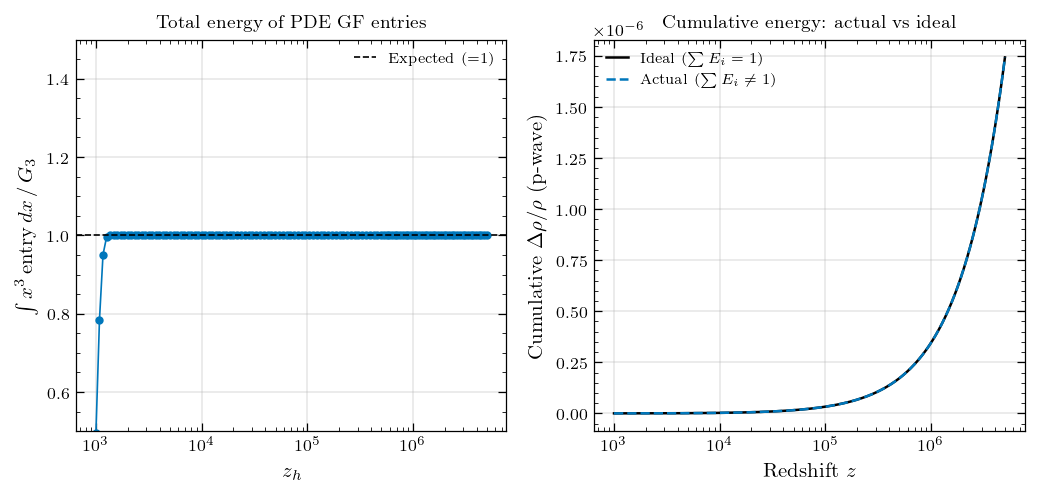


Entry energy statistics:
  min: 0.4960 at z_h = 1e+03
  max: 1.0000 at z_h = 5e+03
  mean: 0.9934
  entries with E < 0.9: 2
  entries with E < 0.5: 1


In [17]:
# Test D Part 4: Check total energy of individual PDE GF entries
# Each entry should have ∫x³ entry dx / G₃ ≈ 1.0 (unit energy per unit Δρ/ρ)
# If entries at high z_h have energy < 1, that explains the convolution energy deficit.

print("=" * 70)
print("Part 4: Total energy of individual PDE GF entries")
print("=" * 70)
print(f"\n{'z_h':>10} {'∫x³·entry/G₃':>14} {'DT/T':>10} {'E_gbb':>10} {'E_mu+y':>10}")
print("-" * 56)

entry_energies = []
for j, zh in enumerate(z_h_pde):
    # Use exact table column (no interpolation)
    entry = pde_gf_table[:, j]  # Δn per unit Δρ/ρ
    
    dx = np.diff(x_pde_gf)
    xm = 0.5 * (x_pde_gf[:-1] + x_pde_gf[1:])
    em = 0.5 * (entry[:-1] + entry[1:])
    total_energy = np.sum(xm**3 * em * dx) / G3
    entry_energies.append(total_energy)

entry_energies = np.array(entry_energies)

# Print selected entries
test_zh_idx = [0, 5, 10, 20, 40, 60, 80, 100, 110, 115, 117]
for j in test_zh_idx:
    if j >= len(z_h_pde):
        continue
    zh = z_h_pde[j]
    entry = pde_gf_table[:, j]
    
    gbb = compute_g_bb(x_pde_gf)
    dx = np.diff(x_pde_gf)
    xm = 0.5 * (x_pde_gf[:-1] + x_pde_gf[1:])
    em = 0.5 * (entry[:-1] + entry[1:])
    gbbm = 0.5 * (gbb[:-1] + gbb[1:])
    
    total_e = np.sum(xm**3 * em * dx) / G3
    int_x2_dn = np.sum(xm**2 * em * dx)
    int_x2_gbb = np.sum(xm**2 * gbbm * dx)
    dtt = int_x2_dn / int_x2_gbb
    e_gbb = 4 * dtt
    e_muy = total_e - e_gbb
    
    print(f"{zh:10.1e} {total_e:14.4f} {dtt:10.4f} {e_gbb:10.4f} {e_muy:10.4f}")

# Plot entry energy vs z_h
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(DOUBLE_COL, 3.5))

ax1.plot(z_h_pde, entry_energies, "o-", color=C["blue"], markersize=3, lw=LW_THIN)
ax1.axhline(1.0, color="k", ls="--", lw=LW_THIN, label="Expected (=1)")
ax1.set_xscale("log")
ax1.set_xlabel(r"$z_h$")
ax1.set_ylabel(r"$\int x^3 \, \mathrm{entry} \, dx \, / \, G_3$")
ax1.set_title("Total energy of PDE GF entries")
ax1.legend(fontsize=LEGEND_SIZE)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.5, 1.5)

# Also plot cumulative energy: the p-wave integrand weighted by entry energy
# vs weighted by 1.0 (what it should be)
dq_pw = ct_heating["p-wave"]
ln_min = np.log(1.0 + Z_END)
ln_max = np.log(1.0 + Z_START)

# Compute the actual and ideal total energy from the convolution
n_quad = 500
ln_grid = np.linspace(ln_min, ln_max, n_quad)
cum_actual = np.zeros(n_quad)
cum_ideal = np.zeros(n_quad)
for j in range(n_quad):
    z_j = np.exp(ln_grid[j]) - 1.0
    heating = dq_pw(z_j) * (1.0 + z_j)  # d(Δρ/ρ)/d(ln(1+z))
    
    # Entry energy at this z_j (interpolated)
    idx = np.searchsorted(z_h_pde, z_j)
    if idx == 0:
        e_j = entry_energies[0]
    elif idx >= len(z_h_pde):
        e_j = entry_energies[-1]
    else:
        # Linear interpolation in log z
        f = (np.log10(z_j) - np.log10(z_h_pde[idx-1])) / \
            (np.log10(z_h_pde[idx]) - np.log10(z_h_pde[idx-1]))
        e_j = entry_energies[idx-1] + f * (entry_energies[idx] - entry_energies[idx-1])
    
    dln = ln_grid[1] - ln_grid[0]
    cum_actual[j] = cum_actual[j-1] + heating * e_j * dln if j > 0 else heating * e_j * dln * 0.5
    cum_ideal[j] = cum_ideal[j-1] + heating * 1.0 * dln if j > 0 else heating * 1.0 * dln * 0.5

z_grid = np.exp(ln_grid) - 1.0
ax2.plot(z_grid, cum_ideal, "k-", lw=LW, label=r"Ideal ($\sum E_i = 1$)")
ax2.plot(z_grid, cum_actual, color=C["blue"], ls="--", lw=LW,
         label=r"Actual ($\sum E_i \neq 1$)")
ax2.set_xscale("log")
ax2.set_xlabel(r"Redshift $z$")
ax2.set_ylabel(r"Cumulative $\Delta\rho/\rho$ (p-wave)")
ax2.set_title("Cumulative energy: actual vs ideal")
ax2.legend(fontsize=LEGEND_SIZE)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig("../figures/pde_gf_entry_energy.pdf", dpi=SAVE_DPI)
plt.show()

print(f"\nEntry energy statistics:")
print(f"  min: {entry_energies.min():.4f} at z_h = {z_h_pde[np.argmin(entry_energies)]:.0e}")
print(f"  max: {entry_energies.max():.4f} at z_h = {z_h_pde[np.argmax(entry_energies)]:.0e}")
print(f"  mean: {entry_energies.mean():.4f}")
print(f"  entries with E < 0.9: {np.sum(entry_energies < 0.9)}")
print(f"  entries with E < 0.5: {np.sum(entry_energies < 0.5)}")